# HDBSCAN Hyperparameter Tuning

This notebook optimizes HDBSCAN clustering parameters for article summaries using Optuna.

## TODOs

- use train / xval sets, evaluate in xval, maybe 5 k-fold xvals
- do longer optuna with a couple hundred tests
- add params: pca v umap
- do once with dbscan and once with hdbscan
- give it 200 test inputs and compare vs a canonical clustering

In [1]:
import dotenv
from typing import List, Dict, Any, Optional
from collections import Counter
from functools import partial
import os
import glob
import sqlite3
import pickle
import json
from pathlib import Path
from datetime import datetime
import time

import numpy as np
import pandas as pd
import openai
from openai import RateLimitError, APIError

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import TruncatedSVD
import umap
import hdbscan
import optuna

import warnings
warnings.filterwarnings('ignore')

dotenv.load_dotenv()

True

In [2]:
# Configuration parameters

# Minimum components for dimensionality reduction
# Below 50, clustering becomes unstable for our 3072-dim embeddings
MIN_COMPONENTS = 50

# Number of Optuna optimization trials
# 100 trials takes ~30-45 minutes; increase for better results
N_TRIALS = 100

# Random seed for reproducibility
RANDOM_STATE = 42

# OpenAI embedding model
# text-embedding-3-large: 3072 dims, $0.00013/1K tokens
EMBEDDING_MODEL = "text-embedding-3-large"

# Cache file for embeddings (to avoid regenerating)
EMBEDDINGS_CACHE = "embeddings.pkl"

In [3]:
# Connect to SQLite and load articles into a DataFrame
# Note: topics field is now available in the articles table
# Consider adding it to this query for topic-aware clustering evaluation

db_path = "newsletter_agent.db"
query = """
SELECT *
FROM articles
WHERE short_summary IS NOT NULL and short_summary != '' and content_length > 100
"""

with sqlite3.connect(db_path) as conn:
    headline_df = pd.read_sql_query(query, conn)

print(f"Loaded {len(headline_df)} unique rows with non-null summaries")
headline_df.head()

Loaded 22259 unique rows with non-null summaries


,id,final_url,url,source,title,published,rss_summary,isAI,status,html_path,...,summary,short_summary,description,rating,cluster_label,domain,site_name,reputation,date,topics
0,721,https://www.ft.com/content/ea3d20ed-5b42-45ce-...,https://t.co/bhcd7nguvj,Techmeme,A draft proposal outlines the European Commiss...,NaN,NaN,1,200,download/html/A_draft_proposal_outlines_the_Eu...,...,- The EU is developing a new AI strategy aimed...,"A draft European Commission proposal, to be pr...",Brussels to unveil plan targeting digital sove...,6.231039,,ft.com,Financial Times,5.0,NaN,NaN
1,940,https://www.ft.com/content/c4b5153f-be07-454d-...,https://t.co/nn6cRhGN5w,Techmeme,AstraZeneca signs $555mn AI deal to identify i...,NaN,NaN,1,200,download/html/AstraZeneca_signs__555mn_AI_deal...,...,- AstraZeneca has entered into a $555 million ...,AstraZeneca has signed a $555 million deal to ...,Pharmaceutical company is latest to invest in ...,6.352663,,ft.com,Financial Times,5.0,NaN,NaN
2,1043,https://www.ft.com/content/934cc94b-32c4-497e-...,https://t.co/pdyStQgIsr,Techmeme,Deloitte says it will partially refund payment...,NaN,NaN,1,200,download/html/Deloitte_says_it_will_partially_...,...,- Deloitte issued a refund to the Australian g...,Deloitte will partially refund payment for an ...,Big Four firm will repay final instalment afte...,6.393448,,ft.com,Financial Times,5.0,NaN,NaN
3,1237,https://www.ft.com/content/5f6f78af-aed9-43a5-...,https://t.co/ZF1E09CAyV,Techmeme,"OpenAI's deals with Nvidia, AMD, Oracle, and o...",NaN,NaN,1,200,download/html/OpenAI_s_deals_with_Nvidia__AMD_...,...,- OpenAI has secured computing deals valued at...,OpenAI has secured computing deals worth over ...,"Partners including Nvidia, AMD and Oracle have...",6.510267,,ft.com,Financial Times,5.0,NaN,NaN
4,1238,https://www.ft.com/content/79b53db3-3411-454c-...,https://t.co/1k60xCOelv,Techmeme,Sources: Elon Musk has appointed former Morgan...,NaN,NaN,1,200,download/html/Sources__Elon_Musk_has_appointed...,...,"- Elon Musk appoints Anthony Armstrong, a form...",Sources say Elon Musk has appointed former Mor...,Anthony Armstrong will take over financial man...,6.515726,,ft.com,Financial Times,5.0,NaN,NaN


In [4]:
headline_df['topics']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4                                                      NaN
                               ...                        
22254    Policy And Regulation,Defense,Artificial Intel...
22255    Gen AI,WebGL,Art And Design,Procedural Generat...
22256    Neural Rendering,MLP,Light Transport,HLSL,GPUs...
22257    AI Shopping,Online Shopping,E-commerce,Price C...
22258    Humanoid Robots,Robotics,Artificial intelligen...
Name: topics, Length: 22259, dtype: str

In [5]:
from do_cluster import _create_short_summary

# def get_input_text(row):
#     retval = ""
#     if pd.notna(row['short_summary']) and len(str(row['short_summary'])):
#         short_summary = str(row['short_summary']).strip()
#         retval += short_summary
#         topics_list = row['topics']
#         topics = str(topics_list).strip() if topics_list else ""
#         if topics:
#             retval += f" Topics: {topics}"
#     return retval

headline_df['input_text'] = headline_df.apply(_create_short_summary, axis=1)


In [7]:
headline_df.iloc[-1].input_text
# delete cache embeddings.pkl

'Ahead of Lunar New Year in Beijing, organizers will deploy humanoid robots — four 95‑cm units and 20 from Booster Robotics — to perform dance, martial arts, Peking Opera and other acts using onboard AI autonomy with human assistance. Topics: Humanoid Robots,Robotics,Artificial intelligence,Autonomy,Public Displays,Tech Startups,China'

In [8]:
min(headline_df["input_text"].str.len())

41

In [9]:
headline_df

,id,final_url,url,source,title,published,rss_summary,isAI,status,html_path,...,short_summary,description,rating,cluster_label,domain,site_name,reputation,date,topics,input_text
0,721,https://www.ft.com/content/ea3d20ed-5b42-45ce-...,https://t.co/bhcd7nguvj,Techmeme,A draft proposal outlines the European Commiss...,NaN,NaN,1,200,download/html/A_draft_proposal_outlines_the_Eu...,...,"A draft European Commission proposal, to be pr...",Brussels to unveil plan targeting digital sove...,6.231039,,ft.com,Financial Times,5.0,NaN,NaN,"A draft European Commission proposal, to be pr..."
1,940,https://www.ft.com/content/c4b5153f-be07-454d-...,https://t.co/nn6cRhGN5w,Techmeme,AstraZeneca signs $555mn AI deal to identify i...,NaN,NaN,1,200,download/html/AstraZeneca_signs__555mn_AI_deal...,...,AstraZeneca has signed a $555 million deal to ...,Pharmaceutical company is latest to invest in ...,6.352663,,ft.com,Financial Times,5.0,NaN,NaN,AstraZeneca has signed a $555 million deal to ...
2,1043,https://www.ft.com/content/934cc94b-32c4-497e-...,https://t.co/pdyStQgIsr,Techmeme,Deloitte says it will partially refund payment...,NaN,NaN,1,200,download/html/Deloitte_says_it_will_partially_...,...,Deloitte will partially refund payment for an ...,Big Four firm will repay final instalment afte...,6.393448,,ft.com,Financial Times,5.0,NaN,NaN,Deloitte will partially refund payment for an ...
3,1237,https://www.ft.com/content/5f6f78af-aed9-43a5-...,https://t.co/ZF1E09CAyV,Techmeme,"OpenAI's deals with Nvidia, AMD, Oracle, and o...",NaN,NaN,1,200,download/html/OpenAI_s_deals_with_Nvidia__AMD_...,...,OpenAI has secured computing deals worth over ...,"Partners including Nvidia, AMD and Oracle have...",6.510267,,ft.com,Financial Times,5.0,NaN,NaN,OpenAI has secured computing deals worth over ...
4,1238,https://www.ft.com/content/79b53db3-3411-454c-...,https://t.co/1k60xCOelv,Techmeme,Sources: Elon Musk has appointed former Morgan...,NaN,NaN,1,200,download/html/Sources__Elon_Musk_has_appointed...,...,Sources say Elon Musk has appointed former Mor...,Anthony Armstrong will take over financial man...,6.515726,,ft.com,Financial Times,5.0,NaN,NaN,Sources say Elon Musk has appointed former Mor...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22254,28300,https://www.politico.eu/article/poll-one-in-th...,https://www.politico.eu/article/poll-one-in-th...,NewsAPI,"One in three Germans welcome killer robots, ne...",2026-02-13T09:22:14+00:00,NaN,1,200,download/html/One_in_three_Germans_welcome_kil...,...,A POLITICO poll finds one in three Germans fav...,AI-enabled technologies like drones are transf...,3.687164,Public Debate Over AI Risks,politico.eu,Politico,0.0,2026-02-14T14:49:32.648585+00:00,"Policy And Regulation,Defense,Artificial Intel...",A POLITICO poll finds one in three Germans fav...
22255,28301,https://prompttoplanet.n4ze3m.com/,https://prompttoplanet.n4ze3m.com/,Hacker News,"Show HN: Prompt to Planet, generate procedural...",2026-02-14T08:05:47+00:00,"<a href=""https://news.ycombinator.com/item?id=...",1,200,download/html/Show_HN__Prompt_to_Planet__gener...,...,"Prompt to Planet generates procedural, interac...",,1.828419,Text-to-Media AI Tools,n4ze3m.com,Nazeem,0.0,2026-02-14T14:49:32.648585+00:00,"Gen AI,WebGL,Art And Design,Procedural Generat...","Prompt to Planet generates procedural, interac..."
22256,28302,https://interplayoflight.wordpress.com/2026/02...,https://interplayoflight.wordpress.com/2026/02...,Hacker News,Adventures in Neural Rendering,2026-02-10T21:26:16+00:00,"<a href=""https://news.ycombinator.com/item?id=...",1,200,download/html/Adventures_in_Neural_Rendering.html,...,The author implemented up to 5-layer GPU MLPs ...,"In recent years, neural networks have started ...",2.750887,Evolving AI Models and Tools,wordpress.com,The Zvi,0.0,2026-02-14T14:49:32.648585+00:00,"Neural Rendering,MLP,Light Transport,HLSL,GPUs...",The author implemented up to 5-layer GPU MLPs ...
22257,28303,https://www.globene

In [10]:
headline_df=headline_df[-10000:]

In [11]:
# Save DataFrame for future reference
headline_df.to_pickle("headline_df.pkl")

In [12]:
# get embeddings
# Initialize the OpenAI client
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY environment variable not set")
client = openai.OpenAI(api_key=api_key)

def get_embeddings(
    texts: List[str],
    model: str = EMBEDDING_MODEL,
    batch_size: int = 200,
    max_retries: int = 3
) -> np.ndarray:
    """
    Generate embeddings for a list of texts with error handling and retry logic.
    
    Args:
        texts: List of text strings to embed
        model: OpenAI embedding model name
        batch_size: Number of texts per API call
        max_retries: Maximum retry attempts for failed API calls
    
    Returns:
        NumPy array of embeddings (n_texts, embedding_dim)
    """
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        
        for attempt in range(max_retries):
            try:
                resp = client.embeddings.create(model=model, input=batch)
                batch_embeddings = [d.embedding for d in resp.data]
                all_embeddings.extend(batch_embeddings)
                
                # Progress indicator every 10 batches
                if (i // batch_size) % 10 == 0:
                    print(f"Processed {i + len(batch)}/{len(texts)} texts...")
                break
                
            except RateLimitError:
                wait_time = 2 ** attempt  # Exponential backoff
                print(f"⚠️  Rate limit hit. Waiting {wait_time}s before retry {attempt+1}/{max_retries}")
                time.sleep(wait_time)
                
            except APIError as e:
                if attempt == max_retries - 1:
                    print(f"❌ API error after {max_retries} attempts: {e}")
                    raise
                print(f"⚠️  API error (attempt {attempt+1}): {e}. Retrying...")
                time.sleep(1)
                
    return np.array(all_embeddings)

# Check if cached embeddings exist
if Path(EMBEDDINGS_CACHE).exists():
    print(f"Loading cached embeddings from {EMBEDDINGS_CACHE}")
    with open(EMBEDDINGS_CACHE, 'rb') as f:
        cache = pickle.load(f)
        if cache['texts'] == headline_df["input_text"].tolist():
            embeddings_array = cache['embeddings']
            print(f"✓ Loaded {len(embeddings_array)} cached embeddings")
        else:
            print("⚠️  Cache invalid (different texts), regenerating embeddings")
            embeddings_array = get_embeddings(headline_df["input_text"].tolist())
            with open(EMBEDDINGS_CACHE, 'wb') as f:
                pickle.dump({'texts': headline_df["input_text"].tolist(), 
                           'embeddings': embeddings_array}, f)
            print(f"✓ Cached embeddings to {EMBEDDINGS_CACHE}")
else:
    print("Generating embeddings (this may take a while)...")
    embeddings_array = get_embeddings(headline_df["input_text"].tolist())
    # Cache for future runs
    with open(EMBEDDINGS_CACHE, 'wb') as f:
        pickle.dump({'texts': headline_df["input_text"].tolist(), 
                   'embeddings': embeddings_array}, f)
    print(f"✓ Cached embeddings to {EMBEDDINGS_CACHE}")

print(f"Embeddings shape: {embeddings_array.shape}")

Loading cached embeddings from embeddings.pkl
⚠️  Cache invalid (different texts), regenerating embeddings
Processed 200/10000 texts...
Processed 2200/10000 texts...
Processed 4200/10000 texts...
Processed 6200/10000 texts...
Processed 8200/10000 texts...
✓ Cached embeddings to embeddings.pkl
Embeddings shape: (10000, 3072)


In [13]:
def calculate_clustering_metrics(
    embeddings_array: np.ndarray,
    labels: np.ndarray,
    clusterer: Optional[hdbscan.HDBSCAN] = None
) -> Dict[str, Any]:
    """
    Calculate various clustering quality metrics for HDBSCAN results.
    
    Args:
        embeddings_array: Original normalized embeddings used for clustering
        labels: Cluster labels from HDBSCAN
        clusterer: Optional HDBSCAN clusterer object
    
    Returns:
        Dictionary of clustering metrics
    """
    # Filter out noise points (-1 labels) for some metrics
    non_noise_mask = labels != -1
    non_noise_embeddings = embeddings_array[non_noise_mask]
    non_noise_labels = labels[non_noise_mask]
    
    metrics = {}
    
    # Basic cluster statistics
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)
    
    metrics['n_clusters'] = n_clusters
    metrics['n_noise_points'] = n_noise
    metrics['noise_ratio'] = n_noise / len(labels)
    
    # Cluster size distribution
    cluster_sizes = Counter(labels[labels != -1])
    if cluster_sizes:
        metrics['avg_cluster_size'] = np.mean(list(cluster_sizes.values()))
        metrics['std_cluster_size'] = np.std(list(cluster_sizes.values()))
        metrics['min_cluster_size'] = min(cluster_sizes.values())
        metrics['max_cluster_size'] = max(cluster_sizes.values())
    
    # Skip other metrics if we have too few clusters or too much noise
    if n_clusters < 2 or len(non_noise_labels) < 2:
        print("Warning: Too few clusters or too much noise for some metrics")
        return metrics
    
    # HDBSCAN-specific metrics
    if clusterer is not None:
        try:
            # Validity index (HDBSCAN's internal metric)
            validity_idx = hdbscan.validity.validity_index(
                embeddings_array, labels, metric='euclidean'
            )
            metrics['hdbscan_validity_index'] = validity_idx
        except Exception as e:
            print(f"Could not compute HDBSCAN validity index: {e}")
        
        # Cluster persistence (stability)
        if hasattr(clusterer, 'cluster_persistence_'):
            metrics['cluster_persistence'] = clusterer.cluster_persistence_
    
    # Scikit-learn clustering metrics (excluding noise points)
    try:
        # Silhouette Score (higher is better, range [-1, 1])
        sil_score = silhouette_score(non_noise_embeddings, non_noise_labels, metric='euclidean')
        metrics['silhouette_score'] = sil_score
        
        # Calinski-Harabasz Index (higher is better)
        ch_score = calinski_harabasz_score(non_noise_embeddings, non_noise_labels)
        metrics['calinski_harabasz_score'] = ch_score
        
        # Davies-Bouldin Index (lower is better)
        db_score = davies_bouldin_score(non_noise_embeddings, non_noise_labels)
        metrics['davies_bouldin_score'] = db_score
        
    except Exception as e:
        print(f"Could not compute sklearn metrics: {e}")
    
    # Custom composite score balancing cluster quality
    if 'silhouette_score' in metrics and 'hdbscan_validity_index' in metrics and n_clusters > 0:
        composite_score = (
            0.5 * max(metrics.get('silhouette_score', 0), 0) +  # Quality component
            0.5 * max(metrics.get('hdbscan_validity_index', 0), 0)
        )
        metrics['composite_score'] = composite_score
    
    return metrics

def print_clustering_summary(metrics: Dict[str, Any]) -> None:
    """Print a nice summary of clustering metrics."""
    print("=== Clustering Quality Metrics ===")
    print(f"Number of clusters: {metrics.get('n_clusters', 'N/A')}")
    print(f"Noise points: {metrics.get('n_noise_points', 'N/A')} ({metrics.get('noise_ratio', 0):.1%})")
    
    if 'avg_cluster_size' in metrics:
        print(f"Average cluster size: {metrics['avg_cluster_size']:.1f} ± {metrics.get('std_cluster_size', 0):.1f}")
        print(f"Cluster size range: {metrics.get('min_cluster_size', 'N/A')} - {metrics.get('max_cluster_size', 'N/A')}")
    
    print("=== Quality Scores ===")
    if 'silhouette_score' in metrics:
        print(f"Silhouette Score: {metrics['silhouette_score']:.3f} (higher is better)")
    if 'calinski_harabasz_score' in metrics:
        print(f"Calinski-Harabasz Score: {metrics['calinski_harabasz_score']:.1f} (higher is better)")
    if 'davies_bouldin_score' in metrics:
        print(f"Davies-Bouldin Score: {metrics['davies_bouldin_score']:.3f} (lower is better)")
    if 'hdbscan_validity_index' in metrics:
        print(f"HDBSCAN Validity Index: {metrics['hdbscan_validity_index']:.3f}")
    if 'composite_score' in metrics:
        print(f"Composite Score: {metrics['composite_score']:.3f} (higher is better)")
    print()

In [14]:
def umap_objective(trial: optuna.Trial, embeddings_array: np.ndarray) -> float:
    """
    Optuna objective function to optimize HDBSCAN hyperparameters jointly with UMAP.
    
    Args:
        trial: Optuna trial object
        reduced_embeddings: Pre-reduced embeddings
    
    Returns:
        Negative composite score (Optuna minimizes, we want to maximize)
    """
    # UMAP hyperparameters to optimize
    
    n_components = trial.suggest_int('n_components', 10, 500)
    n_neighbors = trial.suggest_int('n_neighbors', 10, 50)
    min_dist = trial.suggest_float('min_dist', 0.0, 0.5)

    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=RANDOM_STATE
    )
    reduced_embeddings = reducer.fit_transform(embeddings_array).astype(np.float64)

    # HDBSCAN hyperparameters to optimize
    min_cluster_size = trial.suggest_int('min_cluster_size', 2, 10)
    min_samples = trial.suggest_int('min_samples', 1, min_cluster_size)
            
    try:
        # core_dist_n_jobs=1 prevents nested joblib parallelism that deadlocks on macOS
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            core_dist_n_jobs=1,
        )
        
        labels = clusterer.fit_predict(reduced_embeddings)
        
        # Calculate metrics
        metrics = calculate_clustering_metrics(reduced_embeddings, labels, clusterer)
        
        # Return negative composite score (Optuna minimizes)
        composite_score = metrics.get('composite_score', -1.0)
        
        # Penalize if no valid clusters found or too much noise
        if metrics.get('n_clusters', 0) < 2 or metrics.get('noise_ratio', 1.0) > 0.8:
            composite_score = -1.0
            
        return -composite_score
        
    except Exception as e:
        print(f"Error in trial {trial.number}: {e}")
        return 1.0  # Bad score for failed trials

In [24]:
# min_cluster_size:   9
# min_samples:        8
# n_components:       690

In [25]:
def optimize_hdbscan(
    embeddings_array: np.ndarray,
    n_trials: int = 50,
    # n_jobs: int = 8,
    timeout: Optional[int] = None
) -> Dict[str, Any]:
    """
    Optimize HDBSCAN hyperparameters using Optuna.
    
    Args:
        embeddings_array: Normalized embeddings array
        n_trials: Number of optimization trials
        n_jobs: Number of parallel threads for Optuna trials
        timeout: Maximum time in seconds (None for no limit)
    
    Returns:
        Dictionary with best parameters and results
    """
    n_jobs=1
    print(f"Starting optimization with {n_trials} trials, {n_jobs} parallel jobs...")
    print(f"Original embedding shape: {embeddings_array.shape}")
    
    # Create study
    study = optuna.create_study(
        direction='minimize',  # We return negative composite score
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
    )
    
    # Use partial instead of lambda (picklable, works with n_jobs)
    # n_jobs uses threading; deadlock is avoided by core_dist_n_jobs=1 in HDBSCAN
    objective = partial(umap_objective, reduced_embeddings=embeddings_array)
    
    study.optimize(
        objective,
        n_trials=n_trials,
        # n_jobs=n_jobs,
        timeout=timeout,
        show_progress_bar=True
    )
    
    # Get best parameters
    best_params = study.best_params
    best_score = -study.best_value  # Convert back to positive
    
    print(f"\nOptimization completed!")
    print(f"Best composite score: {best_score:.4f}")
    print(f"Best parameters: {best_params}")
    
    # Test best parameters
    print(f"\n=== Results with Best Parameters ===")
        
    best_labels = best_clusterer.fit_predict(best_embeddings)
    best_metrics = calculate_clustering_metrics(best_embeddings, best_labels, best_clusterer)
    
    print_clustering_summary(best_metrics)
    
    # Save results automatically
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_file = f"optimization_results_{timestamp}.json"
    
    results_summary = {
        'timestamp': timestamp,
        'best_params': best_params,
        'best_score': float(best_score),
        'best_metrics': {k: float(v) if isinstance(v, (int, float, np.number)) else v 
                         for k, v in best_metrics.items() 
                         if isinstance(v, (int, float, np.number))},
        'n_trials': n_trials,
        'config': {
            'MIN_COMPONENTS': MIN_COMPONENTS,
            'N_TRIALS': N_TRIALS,
            'EMBEDDING_MODEL': EMBEDDING_MODEL,
            'n_samples': len(embeddings_array)
        }
    }
    
    with open(results_file, 'w') as f:
        json.dump(results_summary, f, indent=2)
        
    print(f"\n✓ Results saved to {results_file}\n")
    
    # Return results
    return {
        'study': study,
        'best_params': best_params,
        'best_score': best_score,
        'best_metrics': best_metrics,
    }

# Run optimization
results = optimize_hdbscan(embeddings_array, n_trials=N_TRIALS)

[I 2026-02-15 08:35:03,494] A new study created in memory with name: no-name-73a05169-7ef3-41a7-aa3a-9248500c6b15


Starting optimization with 75 trials, 1 parallel jobs...
Original embedding shape: (10000, 3072)


  0%|          | 0/75 [00:00<?, ?it/s]

[I 2026-02-15 08:37:13,139] Trial 0 finished with value: -0.30511995224144306 and parameters: {'n_components': 118, 'n_neighbors': 48, 'min_dist': 0.36599697090570255, 'min_cluster_size': 7, 'min_samples': 2}. Best is trial 0 with value: -0.30511995224144306.
[I 2026-02-15 08:37:50,188] Trial 1 finished with value: -0.38144989968955934 and parameters: {'n_components': 55, 'n_neighbors': 12, 'min_dist': 0.4330880728874676, 'min_cluster_size': 7, 'min_samples': 5}. Best is trial 1 with value: -0.38144989968955934.
[I 2026-02-15 08:39:34,788] Trial 2 finished with value: -0.29016215715477667 and parameters: {'n_components': 15, 'n_neighbors': 49, 'min_dist': 0.41622132040021087, 'min_cluster_size': 3, 'min_samples': 1}. Best is trial 1 with value: -0.38144989968955934.
[I 2026-02-15 08:40:45,342] Trial 3 finished with value: -0.37574921798885413 and parameters: {'n_components': 63, 'n_neighbors': 22, 'min_dist': 0.2623782158161189, 'min_cluster_size': 5, 'min_samples': 2}. Best is trial 1

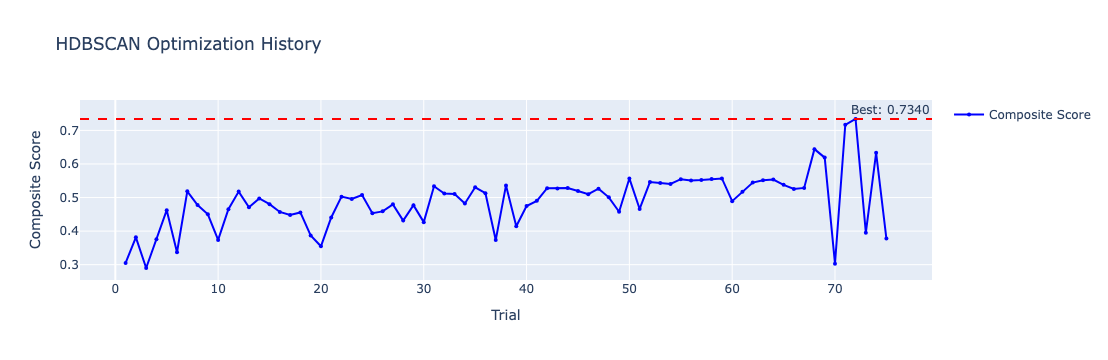

In [26]:
# Plot optimization history
try:
    import plotly.graph_objects as go
    
    trials = results['study'].trials
    values = [-t.value for t in trials if t.value is not None]  # Convert back to positive
    trial_numbers = list(range(1, len(values) + 1))
    
    # Create plot
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=trial_numbers,
        y=values,
        mode='lines+markers',
        name='Composite Score',
        line=dict(color='blue', width=2),
        marker=dict(size=4)
    ))
    
    # Add best score line
    best_score = max(values)
    fig.add_hline(y=best_score, line_dash="dash", line_color="red",
                 annotation_text=f"Best: {best_score:.4f}")
    
    fig.update_layout(
        title='HDBSCAN Optimization History',
        xaxis_title='Trial',
        yaxis_title='Composite Score',
        showlegend=True
    )
    
    fig.show()
    
except ImportError:
    print("Install plotly to visualize optimization history: pip install plotly")

In [15]:
with open(sorted(glob.glob('optimization_results_*.json'))[-1], 'r') as f:
  best_params = json.load(f)['best_params'] 


In [16]:
best_params


{'n_components': 113,
 'n_neighbors': 11,
 'min_dist': 0.4642011193243758,
 'min_cluster_size': 10,
 'min_samples': 10}

In [ ]:
# Display best metrics
print("Best Silhouette Score:", results['best_metrics'].get('silhouette_score', 'N/A'))
print("Best Composite Score:", results['best_metrics'].get('composite_score', 'N/A'))
print("\nBest Parameters:")
for key, value in results['best_params'].items():
    print(f"  {key}: {value}")

In [34]:
# Display best metrics
print("Best Silhouette Score:", results['best_metrics'].get('silhouette_score', 'N/A'))
print("Best Composite Score:", results['best_metrics'].get('composite_score', 'N/A'))
print("\nBest Parameters:")
for key, value in results['best_params'].items():
    print(f"  {key}: {value}")
    

Best Silhouette Score: 0.6296922242827346
Best Composite Score: 0.5071558711386832

Best Parameters:
  n_components: 113
  n_neighbors: 11
  min_dist: 0.4642011193243758
  min_cluster_size: 10
  min_samples: 10


In [17]:
# Save the UMAP reducer for reuse
# best_params = results['best_params']

umap_reducer = umap.UMAP(
        n_components=best_params['n_components'],
        n_neighbors=best_params['n_neighbors'],
        min_dist=best_params['min_dist'],
        random_state=RANDOM_STATE
    )

reduced_embeddings = umap_reducer.fit_transform(embeddings_array).astype(np.float64)

with open('umap_reducer.pkl', 'wb') as f:
    pickle.dump(umap_reducer, f)
print("✓ Saved UMAP reducer to umap_reducer.pkl")

✓ Saved UMAP reducer to umap_reducer.pkl


In [35]:
new_summaries = headline_df["input_text"].sample(n=min(100, len(headline_df)), random_state=RANDOM_STATE).to_list()


In [36]:
# run on a new list of short summaries
with open('umap_reducer.pkl', 'rb') as f:
  umap_reducer = pickle.load(f)

# Load params from most recent file
with open(sorted(glob.glob('optimization_results_*.json'))[-1], 'r') as f:
  params = json.load(f)['best_params']

# Generate embeddings
client = openai.OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
resp = client.embeddings.create(
  model="text-embedding-3-large",
  input=new_summaries
)
embeddings = np.array([d.embedding for d in resp.data])

# Reduce dimensions
reduced = umap_reducer.transform(embeddings).astype(np.float64)

# Cluster
clusterer = hdbscan.HDBSCAN(
  min_cluster_size=params['min_cluster_size'],
  min_samples=params['min_samples'],
  metric="euclidean",
  cluster_selection_method="eom"
)

labels = clusterer.fit_predict(reduced)


array([[0.46061322, 3.84746552, 5.00536966, ..., 3.71131253, 5.08212423,
        6.0790205 ],
       [0.19556499, 5.67658663, 4.95649052, ..., 3.59868813, 5.16295385,
        6.03181362],
       [0.36602318, 3.44627738, 4.8111701 , ..., 3.64769697, 5.11401463,
        6.24711609],
       ...,
       [0.09670488, 6.49832821, 5.13197231, ..., 3.53223991, 5.19339371,
        6.13056231],
       [0.26791197, 5.32323647, 4.89401722, ..., 3.64805198, 5.1486578 ,
        6.02016878],
       [0.11403435, 6.03506708, 4.96097422, ..., 3.56865025, 5.12280893,
        6.03460407]], shape=(100, 113))